# VinDatathon 2026 — Phần 3: Forecasting Pipeline

In [3]:
# !pip install lightgbm prophet --quiet

import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.linear_model import Ridge
from prophet import Prophet
import matplotlib.pyplot as plt
import warnings, logging
warnings.filterwarnings('ignore')
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)
logging.getLogger('prophet').setLevel(logging.WARNING)

In [4]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

DATA_DIR = Path('/content/drive/MyDrive/datathon-2026-round-1')
OUT_DIR  = Path('/content/drive/MyDrive/VinDatathon/outputs')

OUT_DIR.mkdir(parents=True, exist_ok=True)

Mounted at /content/drive


## 1. Load dữ liệu

In [5]:
sales = pd.read_csv(DATA_DIR/'sales.csv', parse_dates=['Date'])
sales['Y']  = sales.Date.dt.year
sales['Q']  = sales.Date.dt.quarter
sales['M']  = sales.Date.dt.month
sales['DOW']= sales.Date.dt.dayofweek
sales['day']= sales.Date.dt.day

print(sales.shape, sales.Date.min().date(), '->', sales.Date.max().date())
sales.head()

(3833, 8) 2012-07-04 -> 2022-12-31


,Date,Revenue,COGS,Y,Q,M,DOW,day
0,2012-07-04,5123547.94,3982991.19,2012,3,7,2,4
1,2012-07-05,2751773.45,2150580.23,2012,3,7,3,5
2,2012-07-06,3054029.42,2517632.84,2012,3,7,4,6
3,2012-07-07,2667930.94,2108246.62,2012,3,7,5,7
4,2012-07-08,2360851.90,1808622.79,2012,3,7,6,8


## 2. EDA

### 2.1 Timeline Revenue & COGS

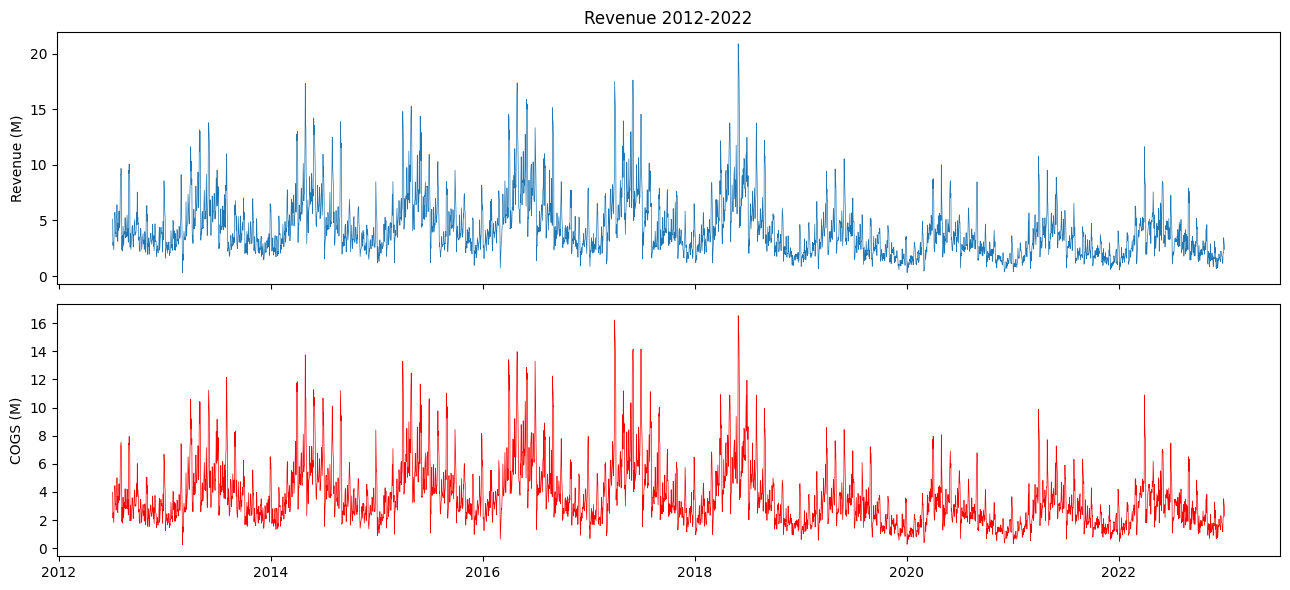

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
axes[0].plot(sales.Date, sales.Revenue/1e6, lw=0.5)
axes[0].set_ylabel('Revenue (M)'); axes[0].set_title('Revenue 2012-2022')
axes[1].plot(sales.Date, sales.COGS/1e6, lw=0.5, color='red')
axes[1].set_ylabel('COGS (M)')
plt.tight_layout(); plt.show()

### 2.2 Monthly seasonality

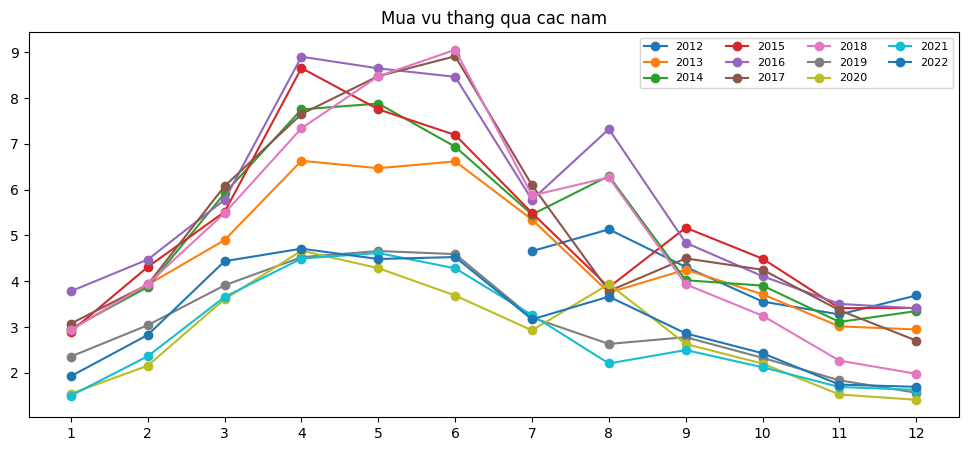

In [7]:
monthly = sales.groupby(['Y','M']).Revenue.mean().reset_index()
fig, ax = plt.subplots(figsize=(12, 5))
for y in sorted(sales.Y.unique()):
    d = monthly[monthly.Y == y]
    ax.plot(d.M, d.Revenue/1e6, marker='o', label=str(y))
ax.set_xticks(range(1,13)); ax.legend(ncol=4, fontsize=8)
ax.set_title('Mua vu thang qua cac nam')
plt.show()

## 3. Feature Engineering


In [8]:
PROMO_SCHEDULE = [
    ('spring_sale',   3, 18, 30, 12, True),
    ('mid_year',      6, 23, 29, 18, True),
    ('fall_launch',   8, 30, 32, 10, True),
    ('year_end',     11, 18, 45, 20, True),
    ('urban_blowout', 7, 30, 33, None, 'odd'),
    ('rural_special', 1, 30, 30, 15,   'odd'),
]

TET_DATES = {
    2013:'2013-02-10', 2014:'2014-01-31', 2015:'2015-02-19',
    2016:'2016-02-08', 2017:'2017-01-28', 2018:'2018-02-16',
    2019:'2019-02-05', 2020:'2020-01-25', 2021:'2021-02-12',
    2022:'2022-02-01', 2023:'2023-01-22', 2024:'2024-02-10',
}

VN_FIXED_HOLIDAYS = [
    (1,1,'new_year'), (3,8,'womens_day'), (4,30,'reunification'),
    (5,1,'labor_day'), (9,2,'national_day'), (10,20,'vn_womens_day'),
    (11,11,'dd_1111'), (12,12,'dd_1212'),
    (12,24,'christmas_eve'), (12,25,'christmas'),
]

In [9]:
def build_features(dates):
    """
    Calendar-only feature builder.

    New EDA-driven addition:
    - August odd/even regime features for Revenue.
    - August odd-year is treated as a discount-suppression regime:
      high discount, lower effective unit price, but COGS does not fall similarly.
    - August even-year / last-week-even captures the observed revenue spike.
    """
    df = pd.DataFrame({'Date': pd.to_datetime(dates)})
    d = df['Date']

    # =====================================================
    # Basic calendar features
    # =====================================================
    df['year']    = d.dt.year
    df['month']   = d.dt.month
    df['day']     = d.dt.day
    df['dow']     = d.dt.dayofweek
    df['doy']     = d.dt.dayofyear
    df['quarter'] = d.dt.quarter
    df['is_weekend']    = (df['dow'] >= 5).astype(int)
    df['days_to_eom']   = d.dt.days_in_month - df['day']
    df['days_from_som'] = df['day'] - 1
    df['dim']           = d.dt.days_in_month

    # Edge-of-month effects
    for k in [1, 2, 3]:
        df[f'is_last{k}']  = (df['days_to_eom'] <= k - 1).astype(int)
        df[f'is_first{k}'] = (df['days_from_som'] <= k - 1).astype(int)

    # =====================================================
    # Trend + regime shift
    # =====================================================
    df['t_days']  = (d - pd.Timestamp('2020-01-01')).dt.days
    df['t_years'] = df['t_days'] / 365.25
    df['t_years2'] = df['t_years'] ** 2

    # Dataset has visible regime shift around 2019 / covid period
    df['regime_pre2019']  = (df['year'] <= 2018).astype(int)
    df['regime_2019']     = (df['year'] == 2019).astype(int)
    df['regime_post2019'] = (df['year'] >= 2020).astype(int)
    df['regime_post2022'] = (df['year'] >= 2022).astype(int)

    # =====================================================
    # Fourier seasonality
    # =====================================================
    TAU = 2 * np.pi

    # Yearly seasonality
    for k in [1, 2, 3, 4, 5]:
        df[f'sin_y{k}'] = np.sin(TAU * k * df['doy'] / 365.25)
        df[f'cos_y{k}'] = np.cos(TAU * k * df['doy'] / 365.25)

    # Weekly seasonality
    for k in [1, 2]:
        df[f'sin_w{k}'] = np.sin(TAU * k * df['dow'] / 7.0)
        df[f'cos_w{k}'] = np.cos(TAU * k * df['dow'] / 7.0)

    # Within-month seasonality
    for k in [1, 2]:
        df[f'sin_m{k}'] = np.sin(TAU * k * (df['day'] - 1) / df['dim'])
        df[f'cos_m{k}'] = np.cos(TAU * k * (df['day'] - 1) / df['dim'])

    # =====================================================
    # Fixed holidays
    # =====================================================
    for (m, dd_, name) in VN_FIXED_HOLIDAYS:
        df[f'hol_{name}'] = ((df['month'] == m) & (df['day'] == dd_)).astype(int)

    # =====================================================
    # Tet distance features
    # =====================================================
    tet_lut = {y: pd.Timestamp(v) for y, v in TET_DATES.items()}

    def nearest_tet_diff(dd):
        cands = [
            tet_lut.get(dd.year),
            tet_lut.get(dd.year - 1),
            tet_lut.get(dd.year + 1),
        ]
        cands = [c for c in cands if c is not None]
        valid = [(dd - c).days for c in cands if abs((dd - c).days) <= 45]
        return min(valid, key=abs) if valid else 999

    diffs = np.array([nearest_tet_diff(dd) for dd in d])
    df['tet_days_diff'] = diffs
    df['tet_abs_diff']  = np.minimum(np.abs(diffs), 60)
    df['tet_in_7']      = (np.abs(diffs) <= 7).astype(int)
    df['tet_in_14']     = (np.abs(diffs) <= 14).astype(int)
    df['tet_before_7']  = ((diffs >= -7) & (diffs < 0)).astype(int)
    df['tet_after_7']   = ((diffs > 0) & (diffs <= 7)).astype(int)
    df['tet_on']        = (diffs == 0).astype(int)

    # =====================================================
    # Black Friday
    # =====================================================
    def is_bf(dd):
        if dd.month != 11:
            return 0
        last = pd.Timestamp(year=dd.year, month=11, day=30)
        last_fri = last - pd.Timedelta(days=(last.dayofweek - 4) % 7)
        return int(dd == last_fri)

    df['hol_black_friday'] = [is_bf(dd) for dd in d]

    # =====================================================
    # Promo windows from the original notebook
    # =====================================================
    yrs = sorted(set(df['year'].tolist()))

    for (name, sm, sd, dur, disc, recur) in PROMO_SCHEDULE:
        in_prom = np.zeros(len(df), dtype=int)
        since   = np.full(len(df), -1.0)
        until   = np.full(len(df), -1.0)
        discount = np.zeros(len(df), dtype=float)

        for y in range(min(yrs) - 1, max(yrs) + 2):
            # True means recurring every year.
            # 'odd' means only odd years.
            if recur == 'odd' and y % 2 == 0:
                continue

            start = pd.Timestamp(year=y, month=sm, day=sd)
            end   = start + pd.Timedelta(days=dur)

            mask = (d >= start) & (d <= end)

            in_prom[mask] = 1
            since[mask] = (d[mask] - start).dt.days
            until[mask] = (end - d[mask]).dt.days
            discount[mask] = disc or 0

        df[f'promo_{name}']       = in_prom
        df[f'promo_{name}_since'] = since
        df[f'promo_{name}_until'] = until
        df[f'promo_{name}_disc']  = discount

    # =====================================================
    # Targeted EDA features: August odd/even discount regime
    # =====================================================
    # EDA finding:
    # - August even years: Revenue spikes, especially last week.
    # - August odd years: Revenue suppressed while COGS pattern remains similar.
    # - Diagnostic tables suggest odd August has much heavier discounting and lower unit price.

    df['is_odd_year']  = (df['year'] % 2 == 1).astype(int)
    df['is_even_year'] = (df['year'] % 2 == 0).astype(int)

    df['is_august']    = (df['month'] == 8).astype(int)
    df['august_odd']   = df['is_august'] * df['is_odd_year']
    df['august_even']  = df['is_august'] * df['is_even_year']

    # Last-week August spike is especially visible in even years.
    df['august_last_week'] = ((df['month'] == 8) & (df['day'] >= 28)).astype(int)
    df['august_last_week_even'] = df['august_last_week'] * df['is_even_year']
    df['august_last_week_odd']  = df['august_last_week'] * df['is_odd_year']

    # Semantic feature name from EDA: odd August = discount-suppression regime.
    df['august_odd_discount_regime'] = df['august_odd']

    # Lightweight interactions with trend.
    df['august_even_x_t'] = df['august_even'] * df['t_years']
    df['august_odd_x_t']  = df['august_odd'] * df['t_years']
    df['august_last_week_even_x_t'] = df['august_last_week_even'] * df['t_years']

    return df


print('Feature test:', build_features(pd.date_range('2023-01-01', '2023-01-05')).shape)

Feature test: (5, 96)


### Auxiliary-table interaction features

This cell builds leakage-safe priors from the auxiliary tables. Since `web_traffic.csv`, `inventory.csv`, and transaction tables stop at 2022, we do not use their future raw values. Instead, we aggregate historical behavior by calendar buckets such as month and month × weekday, then merge those expected patterns into both train and test dates.


In [10]:

# =========================================================
# AUXILIARY-TABLE PRIORS + INTERACTION FEATURES
# =========================================================
# Key idea:
# - Test period has no future web_traffic / inventory / order_items.
# - Therefore we DO NOT use raw future auxiliary values.
# - We build calendar-conditioned historical expectations:
#       month, month x weekday
#   then map them to both train and test.
# - These become demand / discount / inventory priors that are known
#   from historical seasonality only, so they are safe for forecasting.
# =========================================================

def _safe_read_csv(path, parse_dates=None):
    path = Path(path)
    if not path.exists():
        print(f'[WARN] Missing file: {path.name}. Skip related priors.')
        return None
    return pd.read_csv(path, parse_dates=parse_dates)


def _add_expected_prior(df, hist, value_col, keys, out_col):
    """
    Add E[value_col | keys] learned from historical auxiliary table.

    Fallback order:
    - exact bucket keys
    - month-only if available
    - global mean
    """
    df = df.copy()

    if hist is None or hist.empty or value_col not in hist.columns:
        df[out_col] = 0.0
        return df

    tmp = hist.copy()
    for k in keys:
        if k not in tmp.columns:
            df[out_col] = float(tmp[value_col].mean())
            return df

    global_mean = float(tmp[value_col].mean())

    stat = (
        tmp.groupby(keys, dropna=False)[value_col]
        .mean()
        .reset_index()
        .rename(columns={value_col: out_col})
    )

    df = df.merge(stat, on=keys, how='left')

    # fallback to month-level statistic when exact month x dow bucket is missing
    if 'month' in keys and df[out_col].isna().any():
        mstat = (
            tmp.groupby('month', dropna=False)[value_col]
            .mean()
            .reset_index()
            .rename(columns={value_col: out_col + '_m_fallback'})
        )
        df = df.merge(mstat, on='month', how='left')
        df[out_col] = df[out_col].fillna(df[out_col + '_m_fallback'])
        df.drop(columns=[out_col + '_m_fallback'], inplace=True)

    df[out_col] = df[out_col].fillna(global_mean).astype(float)
    return df


def build_auxiliary_history(DATA_DIR):
    """
    Return historical auxiliary tables summarized at daily/monthly level.
    Each returned table contains calendar keys usable for both train and test.
    """
    aux = {}

    # -----------------------------------------------------
    # 1) Web traffic priors
    # -----------------------------------------------------
    web = _safe_read_csv(DATA_DIR / 'web_traffic.csv', parse_dates=['date'])
    if web is not None:
        web = web.rename(columns={'date': 'Date'})
        web_daily = (
            web.groupby('Date', as_index=False)
            .agg(
                web_sessions=('sessions', 'sum'),
                web_unique_visitors=('unique_visitors', 'sum'),
                web_page_views=('page_views', 'sum'),
                web_bounce_rate=('bounce_rate', 'mean'),
                web_avg_duration=('avg_session_duration_sec', 'mean'),
            )
        )
        web_daily['month'] = web_daily['Date'].dt.month
        web_daily['dow'] = web_daily['Date'].dt.dayofweek
        aux['web_daily'] = web_daily
        print('[OK] Built web traffic priors:', web_daily.shape)

    # -----------------------------------------------------
    # 2) Discount / promo priors from orders + order_items
    # -----------------------------------------------------
    orders = _safe_read_csv(DATA_DIR / 'orders.csv', parse_dates=['order_date'])
    items = _safe_read_csv(DATA_DIR / 'order_items.csv')
    if orders is not None and items is not None:
        ord_small = orders[['order_id', 'order_date']].rename(columns={'order_date': 'Date'})
        oi = items.merge(ord_small, on='order_id', how='left')
        oi = oi.dropna(subset=['Date']).copy()

        # unit_price is after discount, so gross proxy = net + discount.
        oi['line_net_value'] = oi['quantity'] * oi['unit_price']
        oi['line_discount'] = oi['discount_amount'].fillna(0.0)
        oi['line_gross_proxy'] = oi['line_net_value'] + oi['line_discount']
        oi['line_discount_ratio'] = (
            oi['line_discount'] / oi['line_gross_proxy'].replace(0, np.nan)
        ).fillna(0.0)

        promo_1 = oi['promo_id'].notna() if 'promo_id' in oi.columns else False
        promo_2 = oi['promo_id_2'].notna() if 'promo_id_2' in oi.columns else False
        oi['has_promo_line'] = (promo_1 | promo_2).astype(int)

        promo_daily = (
            oi.groupby('Date', as_index=False)
            .agg(
                aux_discount_ratio=('line_discount_ratio', 'mean'),
                aux_discount_amount=('line_discount', 'sum'),
                aux_promo_line_rate=('has_promo_line', 'mean'),
                aux_units_sold=('quantity', 'sum'),
                aux_avg_unit_price=('unit_price', 'mean'),
                aux_order_lines=('order_id', 'count'),
            )
        )
        promo_daily['month'] = promo_daily['Date'].dt.month
        promo_daily['dow'] = promo_daily['Date'].dt.dayofweek
        aux['promo_daily'] = promo_daily
        print('[OK] Built order_items discount/promo priors:', promo_daily.shape)

    # -----------------------------------------------------
    # 3) Inventory pressure priors
    # -----------------------------------------------------
    inv = _safe_read_csv(DATA_DIR / 'inventory.csv', parse_dates=['snapshot_date'])
    if inv is not None:
        inv = inv.copy()
        inv['month'] = inv['snapshot_date'].dt.month

        # Inventory is monthly/product-level, so aggregate by month.
        agg_dict = {}
        for c in [
            'stockout_flag',
            'overstock_flag',
            'reorder_flag',
            'sell_through_rate',
            'days_of_supply',
            'fill_rate',
            'stockout_days',
            'units_sold',
            'units_received',
        ]:
            if c in inv.columns:
                agg_dict[c] = 'mean'

        inv_month = inv.groupby('month', as_index=False).agg(agg_dict)
        inv_month = inv_month.rename(columns={
            'stockout_flag': 'aux_inv_stockout_rate',
            'overstock_flag': 'aux_inv_overstock_rate',
            'reorder_flag': 'aux_inv_reorder_rate',
            'sell_through_rate': 'aux_inv_sell_through_rate',
            'days_of_supply': 'aux_inv_days_of_supply',
            'fill_rate': 'aux_inv_fill_rate',
            'stockout_days': 'aux_inv_stockout_days',
            'units_sold': 'aux_inv_units_sold',
            'units_received': 'aux_inv_units_received',
        })
        aux['inv_month'] = inv_month
        print('[OK] Built inventory priors:', inv_month.shape)

    return aux


def add_auxiliary_priors(df, aux):
    """
    Add historical expected priors and interaction features to build_features output.
    """
    out = df.copy()

    # Ensure keys exist.
    if 'month' not in out.columns:
        out['month'] = out['Date'].dt.month
    if 'dow' not in out.columns:
        out['dow'] = out['Date'].dt.dayofweek

    # -----------------------------------------------------
    # Web traffic expected priors
    # -----------------------------------------------------
    web_daily = aux.get('web_daily')
    if web_daily is not None:
        for col in [
            'web_sessions',
            'web_unique_visitors',
            'web_page_views',
            'web_bounce_rate',
            'web_avg_duration',
        ]:
            out = _add_expected_prior(out, web_daily, col, ['month'], f'exp_{col}_month')
            out = _add_expected_prior(out, web_daily, col, ['month', 'dow'], f'exp_{col}_month_dow')

    # -----------------------------------------------------
    # Discount / promo expected priors
    # -----------------------------------------------------
    promo_daily = aux.get('promo_daily')
    if promo_daily is not None:
        for col in [
            'aux_discount_ratio',
            'aux_discount_amount',
            'aux_promo_line_rate',
            'aux_units_sold',
            'aux_avg_unit_price',
            'aux_order_lines',
        ]:
            out = _add_expected_prior(out, promo_daily, col, ['month'], f'exp_{col}_month')
            out = _add_expected_prior(out, promo_daily, col, ['month', 'dow'], f'exp_{col}_month_dow')

    # -----------------------------------------------------
    # Inventory expected priors
    # -----------------------------------------------------
    inv_month = aux.get('inv_month')
    if inv_month is not None:
        out = out.merge(inv_month, on='month', how='left')

    # Fill any missing priors with medians.
    aux_cols = [
        c for c in out.columns
        if c.startswith('exp_') or c.startswith('aux_inv_')
    ]
    for c in aux_cols:
        out[c] = out[c].astype(float)
        out[c] = out[c].fillna(out[c].median() if np.isfinite(out[c].median()) else 0.0)

    # -----------------------------------------------------
    # Interaction features: turn priors into structural signals
    # -----------------------------------------------------
    promo_flag_cols = [
        c for c in out.columns
        if c.startswith('promo_')
        and not c.endswith('_since')
        and not c.endswith('_until')
        and not c.endswith('_disc')
    ]
    if promo_flag_cols:
        out['promo_any'] = out[promo_flag_cols].max(axis=1).astype(int)
    else:
        out['promo_any'] = 0

    # Discount x calendar / regime / August
    if 'exp_aux_discount_ratio_month' in out.columns:
        out['exp_discount_x_promo_any'] = out['exp_aux_discount_ratio_month'] * out['promo_any']
        out['exp_discount_x_post2019'] = out['exp_aux_discount_ratio_month'] * out.get('regime_post2019', 0)
        out['exp_discount_x_august_odd'] = out['exp_aux_discount_ratio_month'] * out.get('august_odd', 0)
        out['exp_discount_x_august_even'] = out['exp_aux_discount_ratio_month'] * out.get('august_even', 0)

    if 'exp_aux_promo_line_rate_month' in out.columns:
        out['exp_promo_rate_x_post2019'] = out['exp_aux_promo_line_rate_month'] * out.get('regime_post2019', 0)
        out['exp_promo_rate_x_august'] = out['exp_aux_promo_line_rate_month'] * out.get('is_august', 0)

    # Traffic x demand calendar
    if 'exp_web_sessions_month_dow' in out.columns:
        out['exp_sessions_x_weekend'] = out['exp_web_sessions_month_dow'] * out.get('is_weekend', 0)
        out['exp_sessions_x_first3'] = out['exp_web_sessions_month_dow'] * out.get('is_first3', 0)
        out['exp_sessions_x_last3'] = out['exp_web_sessions_month_dow'] * out.get('is_last3', 0)
        out['exp_sessions_x_august_even'] = out['exp_web_sessions_month_dow'] * out.get('august_even', 0)

    # Inventory x regime / August
    if 'aux_inv_sell_through_rate' in out.columns:
        out['inv_sellthrough_x_post2019'] = out['aux_inv_sell_through_rate'] * out.get('regime_post2019', 0)
        out['inv_sellthrough_x_august'] = out['aux_inv_sell_through_rate'] * out.get('is_august', 0)

    if 'aux_inv_stockout_rate' in out.columns:
        out['inv_stockout_x_post2019'] = out['aux_inv_stockout_rate'] * out.get('regime_post2019', 0)
        out['inv_stockout_x_last3'] = out['aux_inv_stockout_rate'] * out.get('is_last3', 0)

    # Historical item volume x August / month boundary
    if 'exp_aux_units_sold_month_dow' in out.columns:
        out['exp_units_x_august_even'] = out['exp_aux_units_sold_month_dow'] * out.get('august_even', 0)
        out['exp_units_x_month_end'] = out['exp_aux_units_sold_month_dow'] * out.get('is_last3', 0)

    new_cols = [c for c in out.columns if c.startswith('exp_') or c.startswith('aux_inv_') or c in [
        'promo_any',
        'exp_discount_x_promo_any',
        'exp_discount_x_post2019',
        'exp_discount_x_august_odd',
        'exp_discount_x_august_even',
        'exp_promo_rate_x_post2019',
        'exp_promo_rate_x_august',
        'exp_sessions_x_weekend',
        'exp_sessions_x_first3',
        'exp_sessions_x_last3',
        'exp_sessions_x_august_even',
        'inv_sellthrough_x_post2019',
        'inv_sellthrough_x_august',
        'inv_stockout_x_post2019',
        'inv_stockout_x_last3',
        'exp_units_x_august_even',
        'exp_units_x_month_end',
    ]]
    print(f'[OK] Added auxiliary prior/interactions: {len(new_cols)} columns')
    return out


aux_hist = build_auxiliary_history(DATA_DIR)


[OK] Built web traffic priors: (3652, 8)
[OK] Built order_items discount/promo priors: (3833, 9)
[OK] Built inventory priors: (12, 10)


## 4. Chuẩn bị data train + test

In [11]:
# =========================================================
# BUILD TRAIN / TEST MATRICES
# Less-pruned version:
# - Predict Revenue directly.
# - Predict cost ratio = COGS / Revenue instead of direct COGS.
# - Use target-specific feature sets to avoid semantic mismatch.
# =========================================================

feat = build_features(sales['Date'])

test_dates = pd.date_range('2023-01-01', '2024-07-01', freq='D')
test_df = build_features(test_dates)

# Add leakage-safe priors from auxiliary tables.
feat = add_auxiliary_priors(feat, aux_hist)
test_df = add_auxiliary_priors(test_df, aux_hist)

feat['Revenue'] = sales['Revenue'].values
feat['COGS']    = sales['COGS'].values
feat['cost_ratio'] = feat['COGS'] / feat['Revenue']

NON_FEATURES = {'Date', 'Revenue', 'COGS', 'cost_ratio'}
all_cols = [c for c in feat.columns if c not in NON_FEATURES]

# ---------------------------------------------------------
# Moderate pruning: remove only high-cardinality month_dow priors
# ---------------------------------------------------------
# SHAP showed *_month_dow priors can dominate the model and hurt leaderboard
# generalization. We keep month-level business priors, but remove most
# month x weekday priors to avoid overfitting historical buckets.
noisy_month_dow = [c for c in all_cols if c.endswith('_month_dow')]

# ---------------------------------------------------------
# Revenue feature set
# ---------------------------------------------------------
# Revenue is affected by demand scale. Keep month-level traffic, volume, inventory, promo priors and targeted August features; only remove over-granular month_dow priors.
cols_rev = [c for c in all_cols if c not in noisy_month_dow]

# ---------------------------------------------------------
# Margin / cost-ratio feature set
# ---------------------------------------------------------
# cost_ratio = COGS / Revenue is mainly affected by pricing / discount / regime.
# Do NOT let traffic / volume / inventory pressure dominate this target,
# because these mostly affect demand scale rather than price-cost ratio.
margin_drop_keywords = [
    'web_sessions', 'web_unique_visitors', 'web_page_views', 'web_bounce_rate', 'web_avg_duration',
    'sessions_x_',
    'units_sold', 'order_lines',
    'stockout', 'overstock', 'reorder', 'sell_through', 'days_of_supply', 'fill_rate', 'units_received',
]
cols_margin = []
for c in all_cols:
    if c in noisy_month_dow:
        continue
    if any(k in c for k in margin_drop_keywords):
        continue
    cols_margin.append(c)

# Keep discount / promo / August / calendar / regime features for margin.
# These are semantically aligned with discount pressure and price-cost ratio.

X_rev_tr = feat[cols_rev].values.astype(float)
X_rev_te = test_df[cols_rev].values.astype(float)

X_margin_tr = feat[cols_margin].values.astype(float)
X_margin_te = test_df[cols_margin].values.astype(float)

y_rev = np.log(feat['Revenue'].values)
y_margin = np.log(feat['cost_ratio'].values)

years = feat['Date'].dt.year.values

print(f'Revenue train: {X_rev_tr.shape}, test: {X_rev_te.shape}, features: {len(cols_rev)}')
print(f'Margin train:  {X_margin_tr.shape}, test: {X_margin_te.shape}, features: {len(cols_margin)}')
print(f'Removed noisy month_dow priors: {len(noisy_month_dow)}')

print('\nRevenue aux features kept:')
print([c for c in cols_rev if c.startswith('exp_')][:40])

print('\nMargin aux features kept:')
print([c for c in cols_margin if c.startswith('exp_')][:40])

print('\nMargin dropped examples:')
print([c for c in all_cols if c not in cols_margin][:40])


[OK] Added auxiliary prior/interactions: 48 columns
[OK] Added auxiliary prior/interactions: 48 columns
Revenue train: (3833, 132), test: (548, 132), features: 132
Margin train:  (3833, 110), test: (548, 110), features: 110
Removed noisy month_dow priors: 11

Revenue aux features kept:
['exp_web_sessions_month', 'exp_web_unique_visitors_month', 'exp_web_page_views_month', 'exp_web_bounce_rate_month', 'exp_web_avg_duration_month', 'exp_aux_discount_ratio_month', 'exp_aux_discount_amount_month', 'exp_aux_promo_line_rate_month', 'exp_aux_units_sold_month', 'exp_aux_avg_unit_price_month', 'exp_aux_order_lines_month', 'exp_discount_x_promo_any', 'exp_discount_x_post2019', 'exp_discount_x_august_odd', 'exp_discount_x_august_even', 'exp_promo_rate_x_post2019', 'exp_promo_rate_x_august', 'exp_sessions_x_weekend', 'exp_sessions_x_first3', 'exp_sessions_x_last3', 'exp_sessions_x_august_even', 'exp_units_x_august_even', 'exp_units_x_month_end']

Margin aux features kept:
['exp_aux_discount_ratio_

In [12]:
w_full = np.full(len(years), 0.01)
w_full[(years>=2014) & (years<=2018)] = 1.0
print(f'Days with w=1.0: {(w_full==1.0).sum()}, w=0.01: {(w_full==0.01).sum()}')

Days with w=1.0: 1826, w=0.01: 2007


In [13]:
!pip install -q lightgbm xgboost catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.4 MB/s eta 0:00:00


TIME-SERIES K-FOLD: REVENUE + MARGIN RATIO

===== Fold 2018_H2: val 2018-07-01 -> 2019-01-01 =====
Train rows: 2188 | Val rows: 184
iters rev LGB/CAT: 110/1034
iters margin LGB/CAT: 164/385
VAL MAE Rev=853,528 | COGS=761,550 | Mean=807,539

===== Fold 2019_H2: val 2019-07-01 -> 2020-01-01 =====
Train rows: 2553 | Val rows: 184
iters rev LGB/CAT: 558/2699
iters margin LGB/CAT: 178/574
VAL MAE Rev=539,822 | COGS=506,642 | Mean=523,232

===== Fold 2020_H2: val 2020-07-01 -> 2021-01-01 =====
Train rows: 2919 | Val rows: 184
iters rev LGB/CAT: 996/403
iters margin LGB/CAT: 141/726
VAL MAE Rev=555,927 | COGS=461,925 | Mean=508,926

===== Fold 2021_H2: val 2021-07-01 -> 2022-01-01 =====
Train rows: 3284 | Val rows: 184
iters rev LGB/CAT: 3555/1050
iters margin LGB/CAT: 2696/359
VAL MAE Rev=553,821 | COGS=508,733 | Mean=531,277

===== Fold 2022_H2: val 2022-07-01 -> 2023-01-01 =====
Train rows: 3649 | Val rows: 184
iters rev LGB/CAT: 575/460
iters margin LGB/CAT: 1036/237
VAL MAE Rev=471,184 |

,fold,val_start,val_end,rev_mae,cogs_mae,mean_mae,it_rev_lgb,it_rev_cat,it_margin_lgb,it_margin_cat
0,2018_H2,2018-07-01,2019-01-01,853528.285926,761549.710918,807538.998422,110,1034,164,385
1,2019_H2,2019-07-01,2020-01-01,539821.890190,506642.416754,523232.153472,558,2699,178,574
2,2020_H2,2020-07-01,2021-01-01,555927.396743,461924.580553,508925.988648,996,403,141,726
3,2021_H2,2021-07-01,2022-01-01,553821.461072,508733.227715,531277.344393,3555,1050,2696,359
4,2022_H2,2022-07-01,2023-01-01,471184.360178,411209.220060,441196.790119,575,460,1036,237



CV mean:


,0
rev_mae,594856.678822
cogs_mae,530011.831200
mean_mae,562434.255011



Submission describe:
            Revenue          COGS      Margin
count  5.480000e+02  5.480000e+02  548.000000
mean   4.380159e+06  3.873028e+06    0.893316
std    2.193551e+06  1.921973e+06    0.130725
min    1.174124e+06  9.580732e+05    0.803709
25%    2.642534e+06  2.395846e+06    0.818374
50%    3.914671e+06  3.608965e+06    0.825628
75%    5.632224e+06  4.785237e+06    0.925820
max    1.382843e+07  1.136095e+07    1.384322


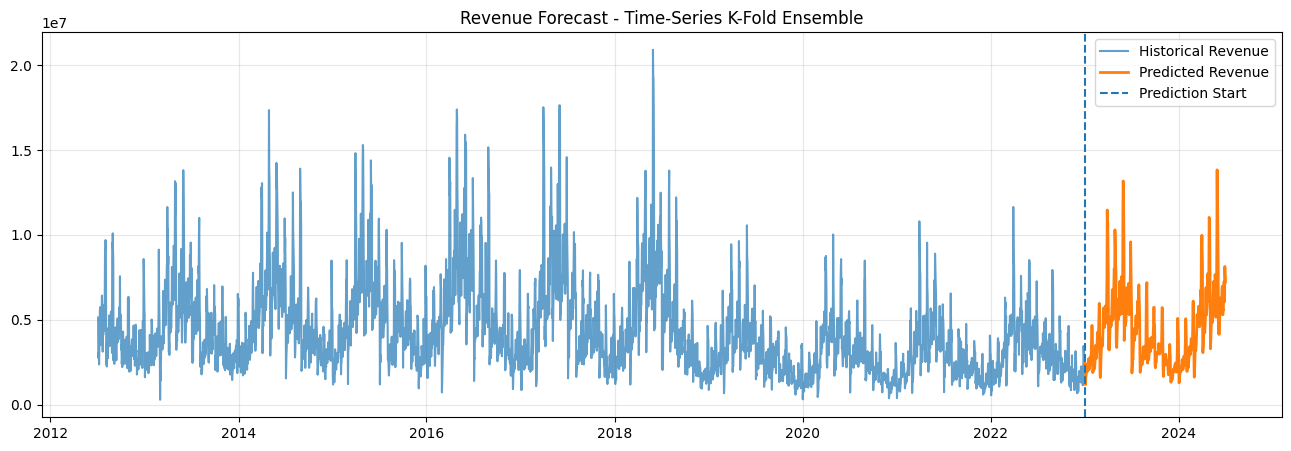

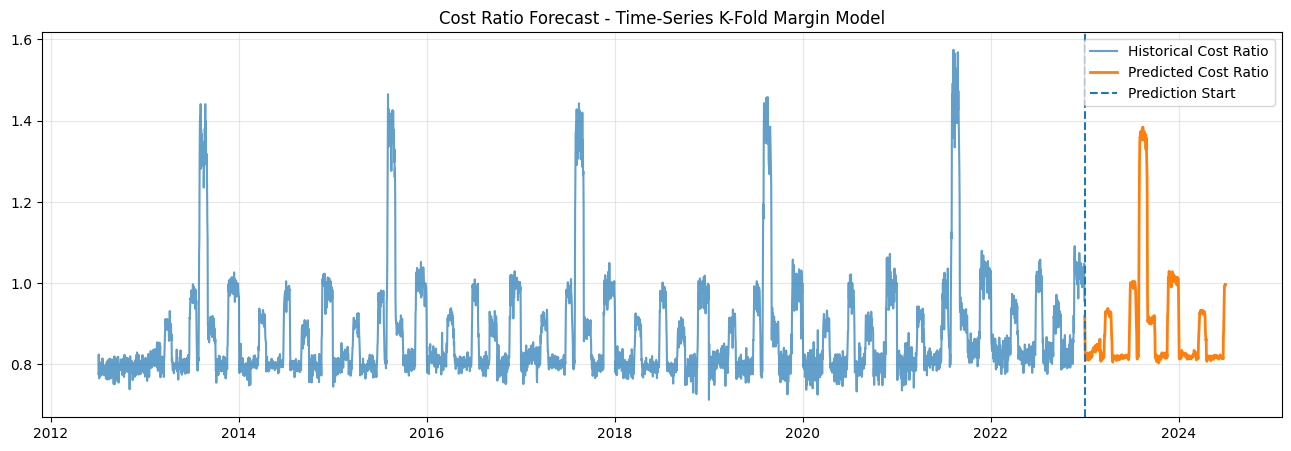


Saved:
/content/drive/MyDrive/VinDatathon/outputs/submission_revenue_margin_ts_kfold.csv


,Date,Revenue,COGS,Margin
0,2023-01-01,2.629805e+06,2.413226e+06,0.917645
1,2023-01-02,1.643932e+06,1.415420e+06,0.860996
2,2023-01-03,1.463127e+06,1.210217e+06,0.827144
3,2023-01-04,1.174124e+06,9.580732e+05,0.815989
4,2023-01-05,1.315336e+06,1.067044e+06,0.811233


In [14]:
# =========================================================
# TIME-SERIES K-FOLD LGB + CAT ENSEMBLE
# Revenue direct + Margin ratio model
# COGS = Revenue * cost_ratio
# =========================================================

print('=' * 80)
print('TIME-SERIES K-FOLD: REVENUE + MARGIN RATIO')
print('=' * 80)

import lightgbm as lgb
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

LGB_PARAMS = dict(
    objective='regression',
    metric='mae',
    learning_rate=0.03,
    num_leaves=63,
    min_data_in_leaf=30,
    feature_fraction=0.85,
    bagging_fraction=0.85,
    bagging_freq=5,
    lambda_l2=1.0,
    seed=42,
    verbosity=-1,
)

CAT_PARAMS = dict(
    loss_function='MAE',
    learning_rate=0.03,
    depth=7,
    iterations=5000,
    l2_leaf_reg=5.0,
    random_seed=42,
    verbose=False,
    allow_writing_files=False,
)

FOLDS = [
    ('2018_H2', '2018-07-01', '2019-01-01'),
    ('2019_H2', '2019-07-01', '2020-01-01'),
    ('2020_H2', '2020-07-01', '2021-01-01'),
    ('2021_H2', '2021-07-01', '2022-01-01'),
    ('2022_H2', '2022-07-01', '2023-01-01'),
]

def get_fold_idx(start, end):
    dates = pd.to_datetime(feat['Date'])
    val_idx = ((dates >= pd.Timestamp(start)) & (dates < pd.Timestamp(end))).values
    train_idx = (dates < pd.Timestamp(start)).values
    return train_idx, val_idx

def train_lgb_fold(X, y, w, train_idx, val_idx, num_boost_es=4000, early_stop=250):
    model = lgb.train(
        LGB_PARAMS,
        lgb.Dataset(X[train_idx], y[train_idx], weight=w[train_idx]),
        num_boost_round=num_boost_es,
        valid_sets=[lgb.Dataset(X[val_idx], y[val_idx])],
        callbacks=[
            lgb.early_stopping(early_stop, verbose=False),
            lgb.log_evaluation(0),
        ],
    )
    return model, model.best_iteration

def train_cat_fold(X, y, w, train_idx, val_idx, early_stop=250):
    model = CatBoostRegressor(**CAT_PARAMS)
    model.fit(
        X[train_idx], y[train_idx],
        sample_weight=w[train_idx],
        eval_set=(X[val_idx], y[val_idx]),
        early_stopping_rounds=early_stop,
        verbose=False,
    )
    return model, model.get_best_iteration() or CAT_PARAMS['iterations']

def ens_pred(lgb_m, cat_m, X, weights):
    wl, wc = weights
    return wl * lgb_m.predict(X) + wc * cat_m.predict(X)

W_REV = (0.35, 0.65)
W_MARGIN = (0.50, 0.50)

test_rev_logs = []
test_margin_logs = []
fold_rows = []

for fold_name, start, end in FOLDS:
    train_idx, val_idx = get_fold_idx(start, end)

    if train_idx.sum() < 500 or val_idx.sum() == 0:
        print(f'Skip {fold_name}: train={train_idx.sum()}, val={val_idx.sum()}')
        continue

    print(f'\n===== Fold {fold_name}: val {start} -> {end} =====')
    print('Train rows:', train_idx.sum(), '| Val rows:', val_idx.sum())

    rev_lgb_f, it_rev_lgb = train_lgb_fold(
        X_rev_tr, y_rev, w_full, train_idx, val_idx,
        num_boost_es=4000, early_stop=250
    )
    rev_cat_f, it_rev_cat = train_cat_fold(
        X_rev_tr, y_rev, w_full, train_idx, val_idx,
        early_stop=250
    )

    margin_lgb_f, it_margin_lgb = train_lgb_fold(
        X_margin_tr, y_margin, w_full, train_idx, val_idx,
        num_boost_es=4000, early_stop=300
    )
    margin_cat_f, it_margin_cat = train_cat_fold(
        X_margin_tr, y_margin, w_full, train_idx, val_idx,
        early_stop=300
    )

    val_rev_log = ens_pred(rev_lgb_f, rev_cat_f, X_rev_tr[val_idx], W_REV)
    val_margin_log = ens_pred(margin_lgb_f, margin_cat_f, X_margin_tr[val_idx], W_MARGIN)

    val_rev = np.exp(val_rev_log)
    val_ratio = np.exp(val_margin_log)

    r_low, r_high = feat['cost_ratio'].quantile([0.005, 0.995])
    val_ratio = np.clip(val_ratio, r_low, r_high)
    val_cog = val_rev * val_ratio

    true_rev = sales.loc[val_idx, 'Revenue'].values
    true_cog = sales.loc[val_idx, 'COGS'].values

    rev_mae = mean_absolute_error(true_rev, val_rev)
    cog_mae = mean_absolute_error(true_cog, val_cog)
    mean_mae = 0.5 * (rev_mae + cog_mae)

    print(f'iters rev LGB/CAT: {it_rev_lgb}/{it_rev_cat}')
    print(f'iters margin LGB/CAT: {it_margin_lgb}/{it_margin_cat}')
    print(f'VAL MAE Rev={rev_mae:,.0f} | COGS={cog_mae:,.0f} | Mean={mean_mae:,.0f}')

    fold_rows.append({
        'fold': fold_name,
        'val_start': start,
        'val_end': end,
        'rev_mae': rev_mae,
        'cogs_mae': cog_mae,
        'mean_mae': mean_mae,
        'it_rev_lgb': it_rev_lgb,
        'it_rev_cat': it_rev_cat,
        'it_margin_lgb': it_margin_lgb,
        'it_margin_cat': it_margin_cat,
    })

    test_rev_logs.append(ens_pred(rev_lgb_f, rev_cat_f, X_rev_te, W_REV))
    test_margin_logs.append(ens_pred(margin_lgb_f, margin_cat_f, X_margin_te, W_MARGIN))

cv_df = pd.DataFrame(fold_rows)
display(cv_df)
print('\nCV mean:')
display(cv_df[['rev_mae', 'cogs_mae', 'mean_mae']].mean())

# average test predictions in log-space
p_rev_log = np.mean(test_rev_logs, axis=0)
p_margin_log = np.mean(test_margin_logs, axis=0)

p_rev = np.exp(p_rev_log)
p_ratio = np.exp(p_margin_log)

r_low, r_high = feat['cost_ratio'].quantile([0.005, 0.995])
p_ratio = np.clip(p_ratio, r_low, r_high)

# =========================================================
# Calibration
# =========================================================

CR = 1.06
CMARGIN = 1.02

final_rev = p_rev * CR
final_ratio = np.clip(p_ratio * CMARGIN, r_low, r_high)
final_cog = final_rev * final_ratio

submission = pd.DataFrame({
    'Date': pd.to_datetime(test_dates),
    'Revenue': final_rev,
    'COGS': final_cog,
})
submission['Margin'] = submission['COGS'] / submission['Revenue']

print('\nSubmission describe:')
print(submission[['Revenue', 'COGS', 'Margin']].describe())

plt.figure(figsize=(16,5))
plt.plot(sales['Date'], sales['Revenue'], alpha=0.7, label='Historical Revenue')
plt.plot(submission['Date'], submission['Revenue'], linewidth=2, label='Predicted Revenue')
plt.axvline(pd.Timestamp('2023-01-01'), linestyle='--', label='Prediction Start')
plt.title('Revenue Forecast - Time-Series K-Fold Ensemble')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(16,5))
plt.plot(sales['Date'], sales['COGS'] / sales['Revenue'], alpha=0.7, label='Historical Cost Ratio')
plt.plot(submission['Date'], submission['Margin'], linewidth=2, label='Predicted Cost Ratio')
plt.axvline(pd.Timestamp('2023-01-01'), linestyle='--', label='Prediction Start')
plt.title('Cost Ratio Forecast - Time-Series K-Fold Margin Model')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

submission_save = submission.copy()
submission_save['Date'] = submission_save['Date'].dt.strftime('%Y-%m-%d')

submission_path = OUT_DIR / 'submission_revenue_margin_ts_kfold.csv'
submission_save[['Date', 'Revenue', 'COGS']].to_csv(submission_path, index=False)

print('\nSaved:')
print(submission_path)

submission_save.head()


Revenue_LGB_last_fold


,feature,mean_abs_shap
0,exp_web_sessions_month,0.234813
1,t_days,0.193167
2,sin_m1,0.074392
3,sin_y2,0.068724
4,days_to_eom,0.054058
5,exp_web_unique_visitors_month,0.047591
6,cos_m1,0.039896
7,cos_y1,0.036624
8,day,0.034039
9,t_years,0.028387


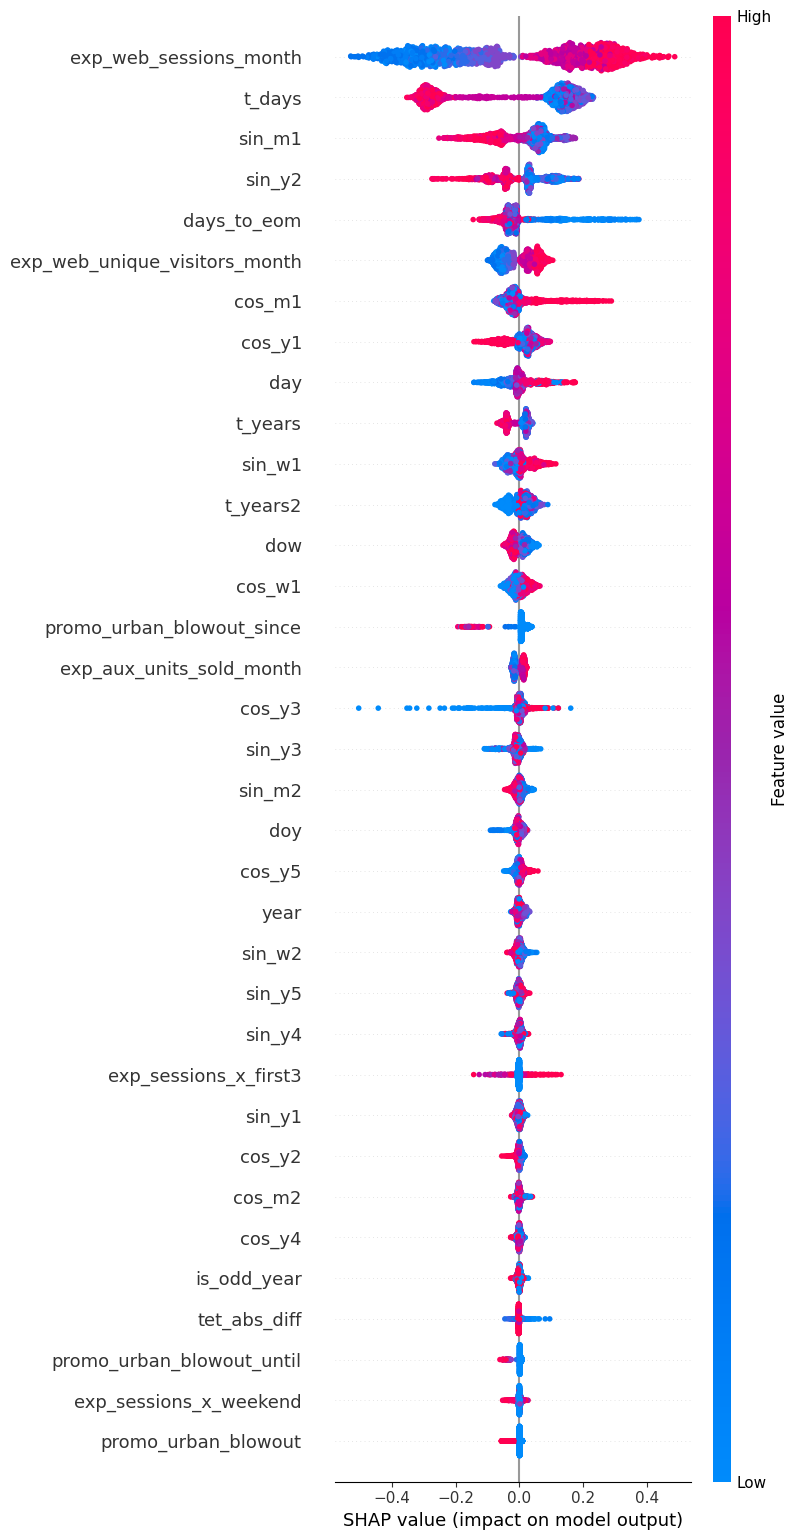

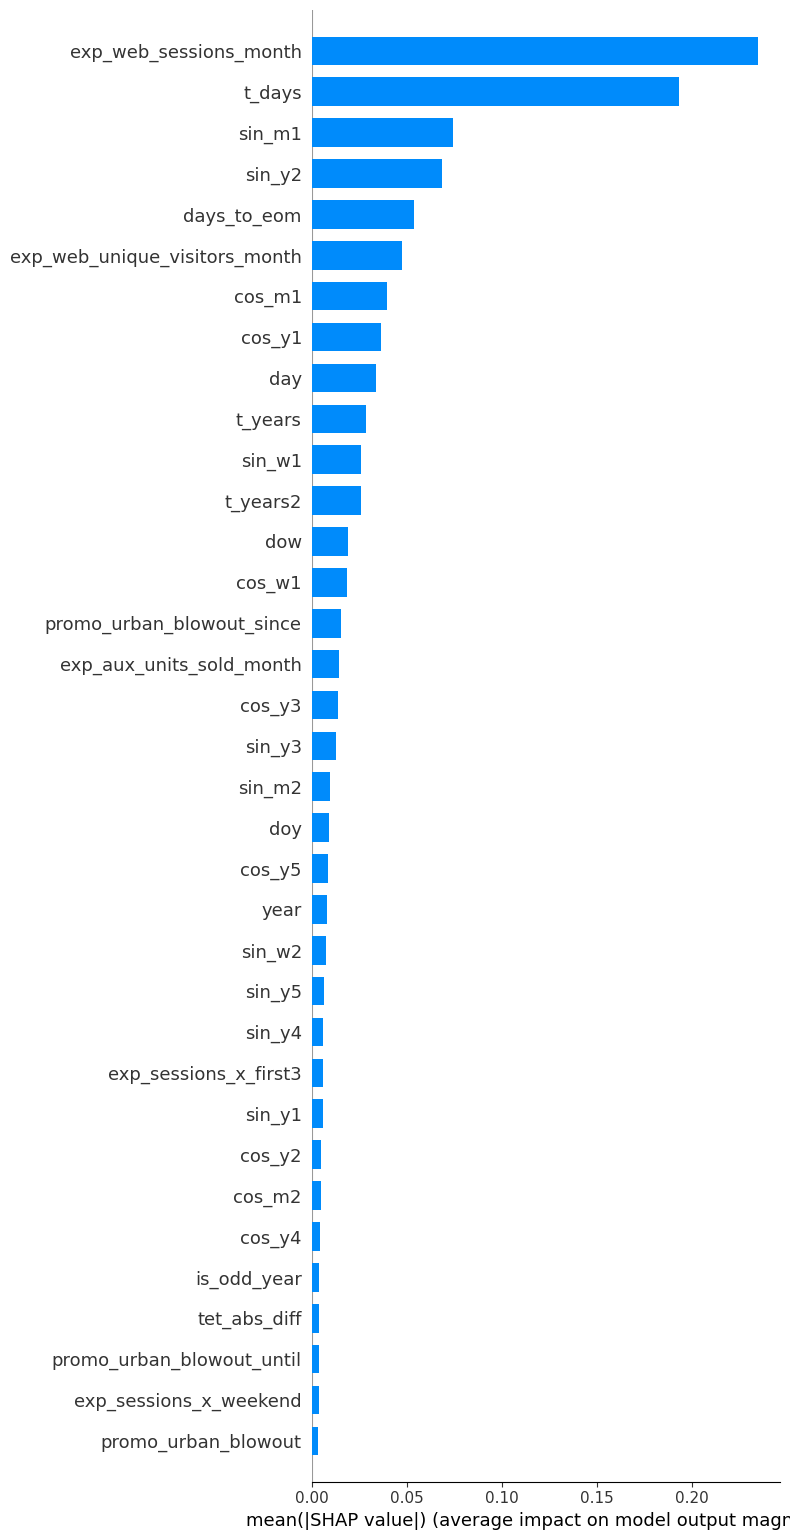


GROUP IMPORTANCE:


,group,n_features,group_shap_sum,top_features
0,calendar_seasonality,45,0.706500,"[exp_web_sessions_month, sin_m1, sin_y2, exp_w..."
1,trend_regime,53,0.303906,"[t_days, t_years, t_years2, promo_urban_blowou..."
2,traffic,9,0.298816,"[exp_web_sessions_month, exp_web_unique_visito..."
3,discount_promo,35,0.040111,"[promo_urban_blowout_since, promo_urban_blowou..."
4,inventory,13,0.007624,"[aux_inv_units_sold, aux_inv_stockout_rate, au..."
5,margin_cost,2,0.002540,"[exp_web_avg_duration_month, exp_aux_discount_..."
6,category_streetwear_outdoor,0,0.000000,[]



Revenue_CAT_last_fold


,feature,mean_abs_shap
0,sin_m1,0.059105
1,t_days,0.055333
2,t_years,0.052017
3,t_years2,0.049708
4,exp_web_sessions_month,0.034978
5,sin_m2,0.034148
6,exp_web_page_views_month,0.032921
7,exp_web_unique_visitors_month,0.032747
8,days_to_eom,0.029401
9,cos_y1,0.028427


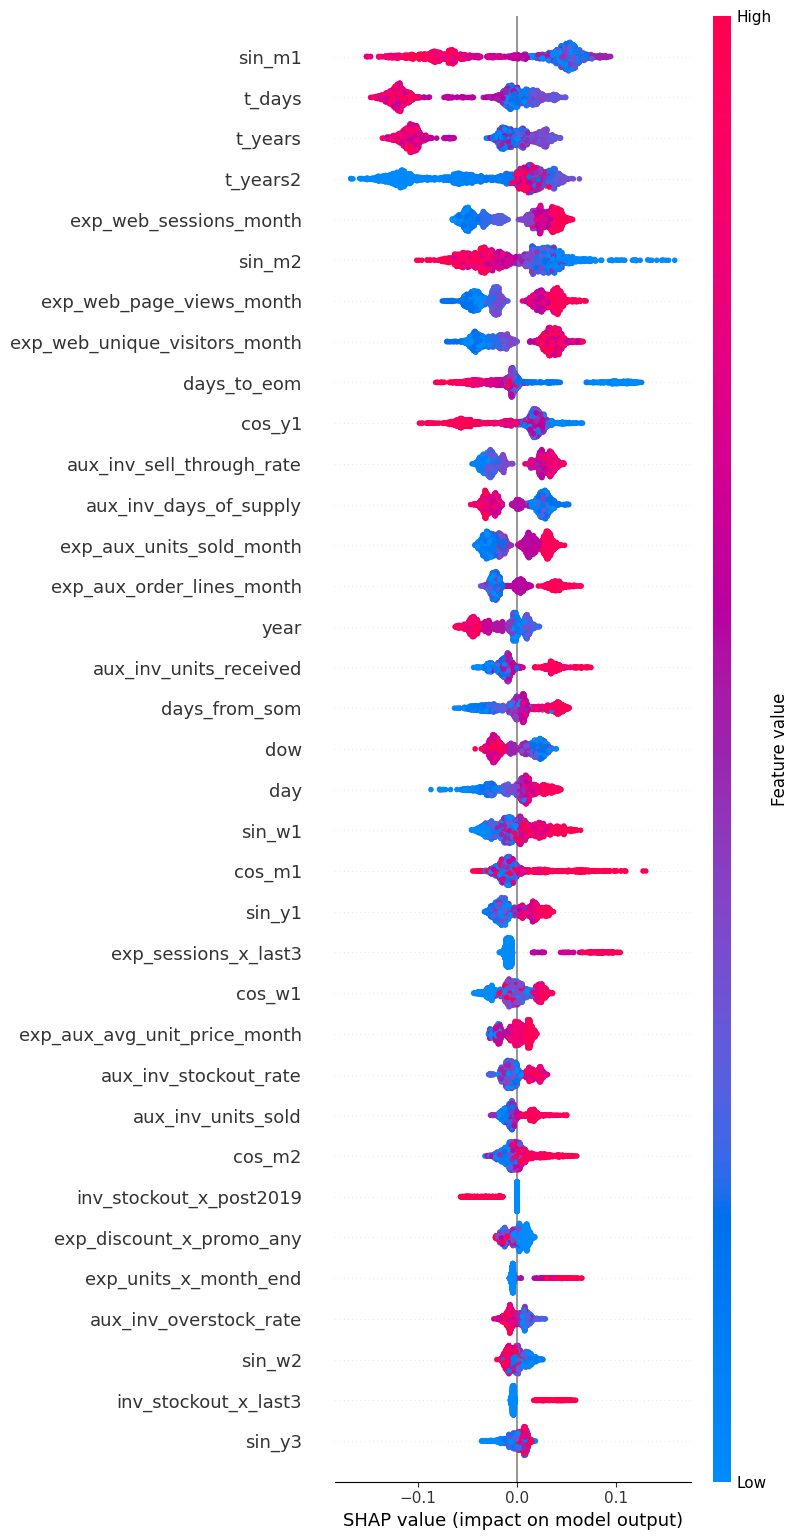

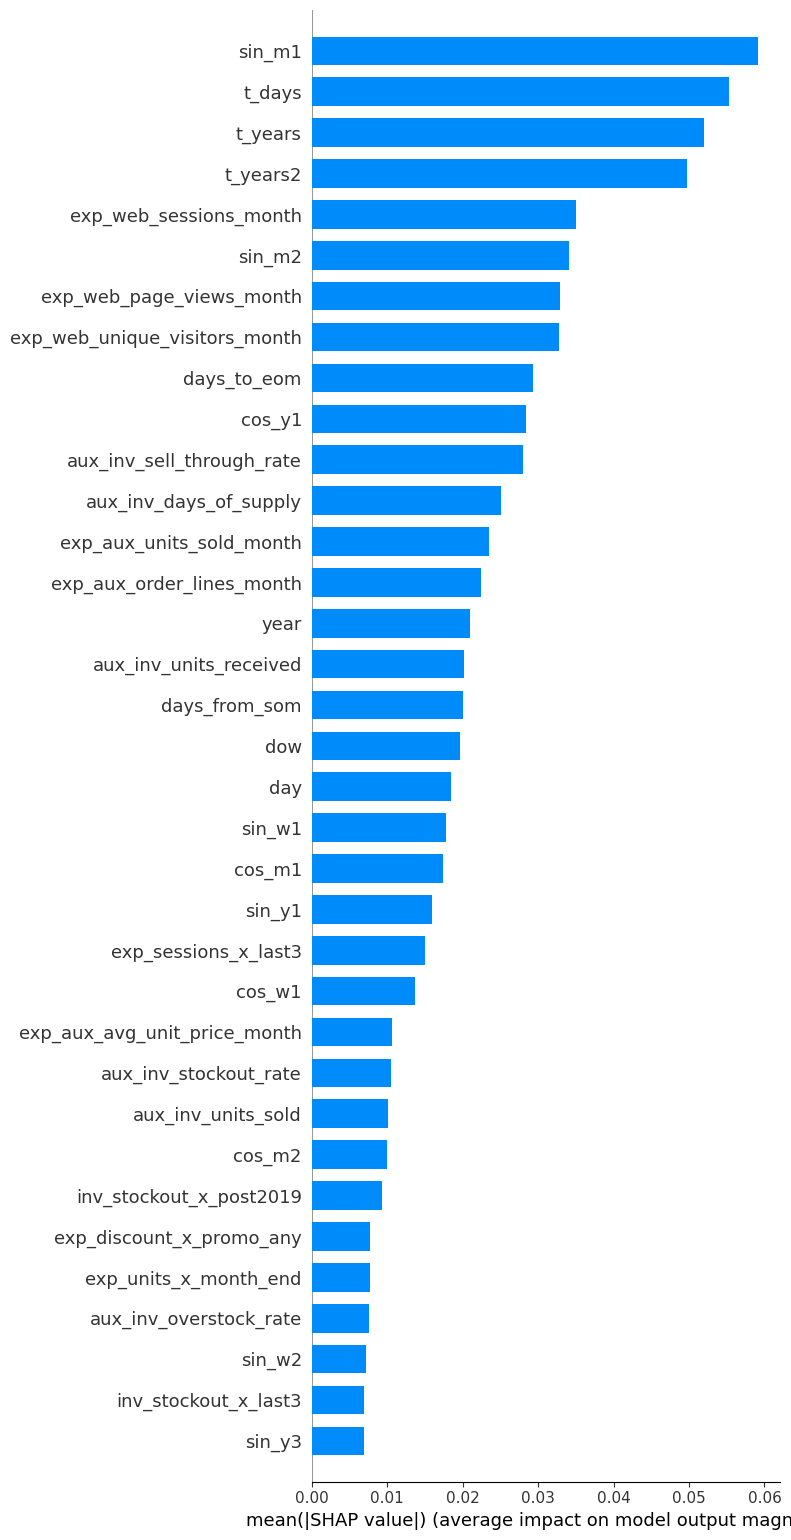


GROUP IMPORTANCE:


,group,n_features,group_shap_sum,top_features
0,calendar_seasonality,45,0.461317,"[sin_m1, exp_web_sessions_month, sin_m2, exp_w..."
1,trend_regime,53,0.298527,"[t_days, t_years, t_years2, year, exp_aux_avg_..."
2,traffic,9,0.135326,"[exp_web_sessions_month, exp_web_page_views_mo..."
3,inventory,13,0.132312,"[aux_inv_sell_through_rate, aux_inv_days_of_su..."
4,discount_promo,35,0.050313,"[exp_discount_x_promo_any, exp_promo_rate_x_po..."
5,margin_cost,2,0.009185,"[exp_aux_discount_ratio_month, exp_web_avg_dur..."
6,category_streetwear_outdoor,0,0.000000,[]



Margin_LGB_last_fold


,feature,mean_abs_shap
0,exp_discount_x_promo_any,0.045345
1,promo_urban_blowout_since,0.028598
2,promo_any,0.014411
3,t_days,0.010005
4,cos_y2,0.007488
5,exp_aux_avg_unit_price_month,0.006311
6,t_years2,0.005849
7,sin_y2,0.003323
8,august_odd,0.003247
9,cos_y3,0.001911


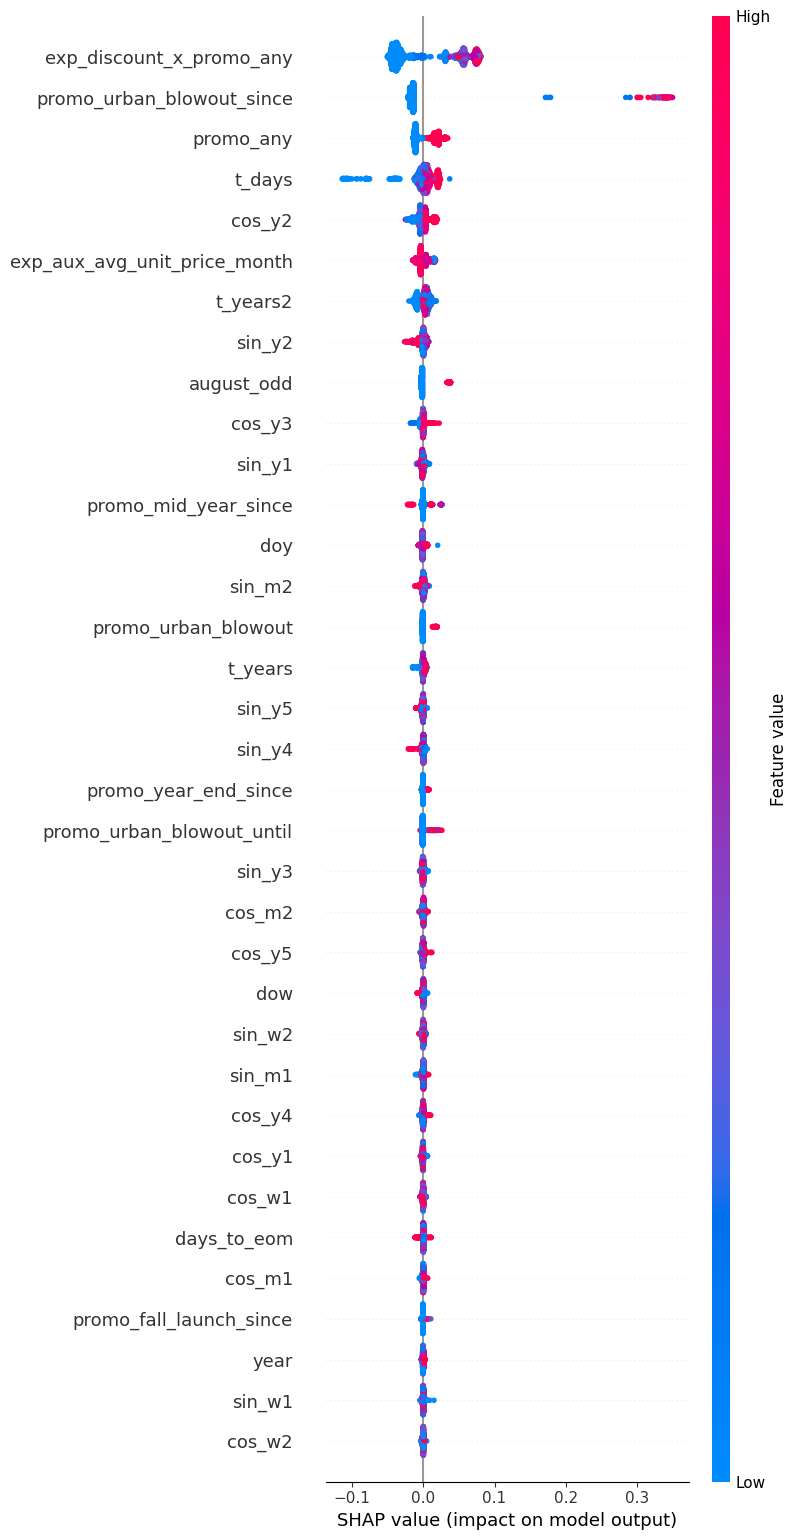

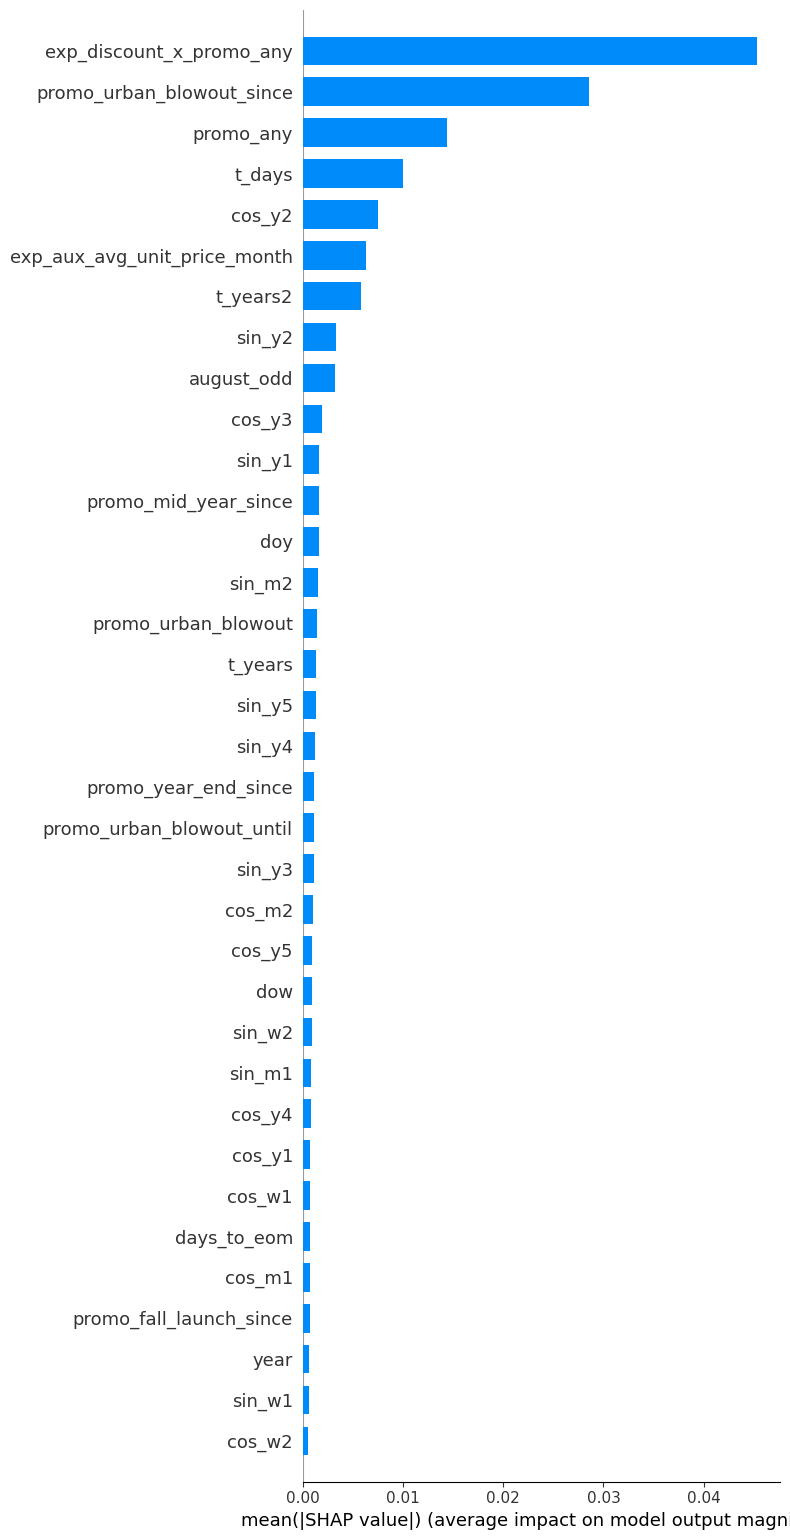


GROUP IMPORTANCE:


,group,n_features,group_shap_sum,top_features
0,trend_regime,48,0.108793,"[exp_discount_x_promo_any, promo_urban_blowout..."
1,discount_promo,35,0.097031,"[exp_discount_x_promo_any, promo_urban_blowout..."
2,calendar_seasonality,37,0.067951,"[promo_urban_blowout_since, cos_y2, exp_aux_av..."
3,margin_cost,1,0.000185,[exp_aux_discount_ratio_month]
4,category_streetwear_outdoor,0,0.000000,[]
5,traffic,0,0.000000,[]
6,inventory,2,0.000000,"[inv_sellthrough_x_august, inv_sellthrough_x_p..."



Margin_CAT_last_fold


,feature,mean_abs_shap
0,promo_any,0.031649
1,exp_discount_x_promo_any,0.028407
2,exp_aux_avg_unit_price_month,0.009683
3,sin_y3,0.006249
4,promo_urban_blowout_since,0.003215
5,t_years2,0.003107
6,sin_y2,0.002757
7,month,0.002678
8,august_odd_x_t,0.002662
9,cos_y2,0.002647


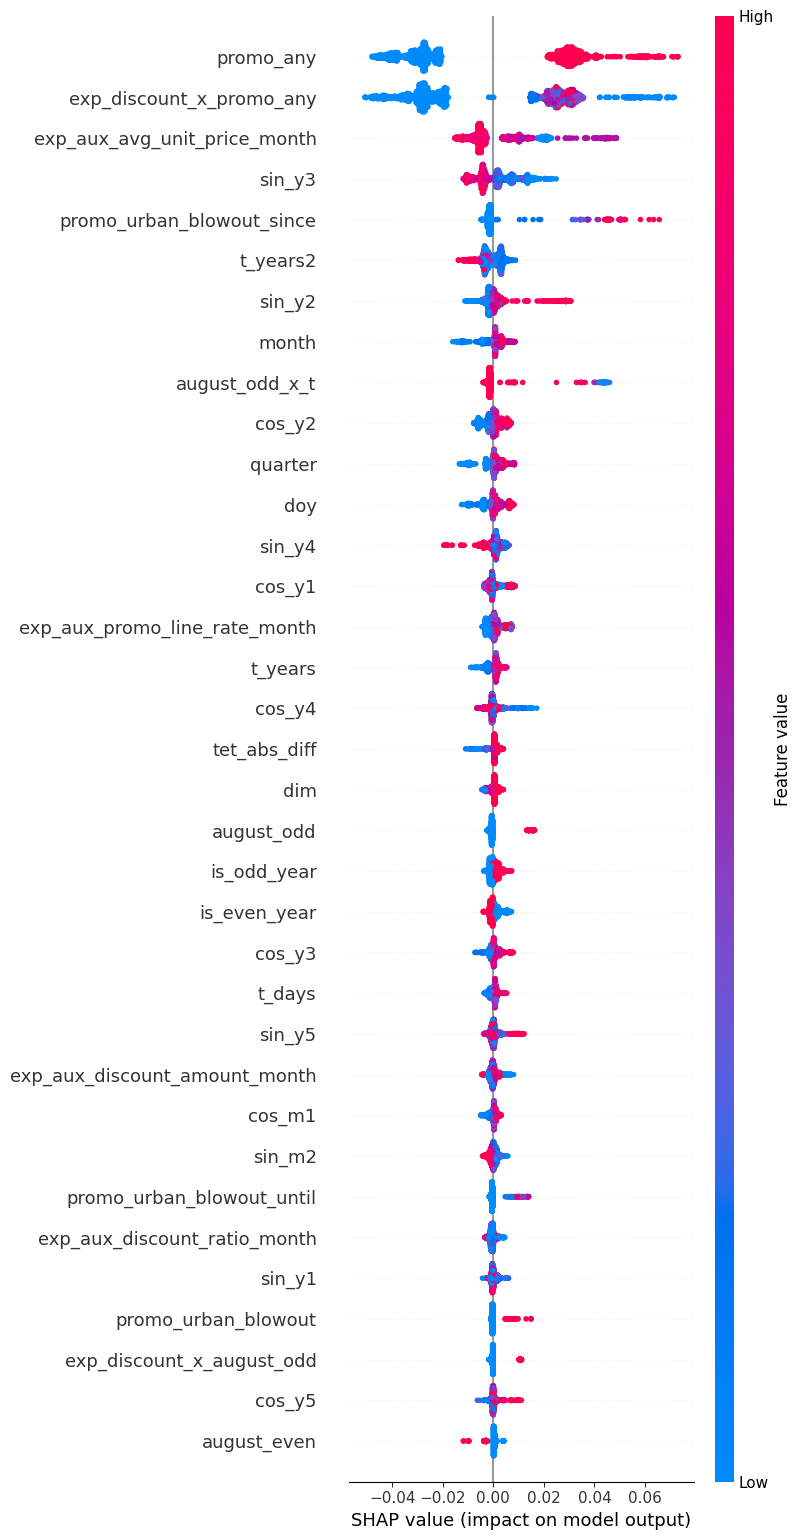

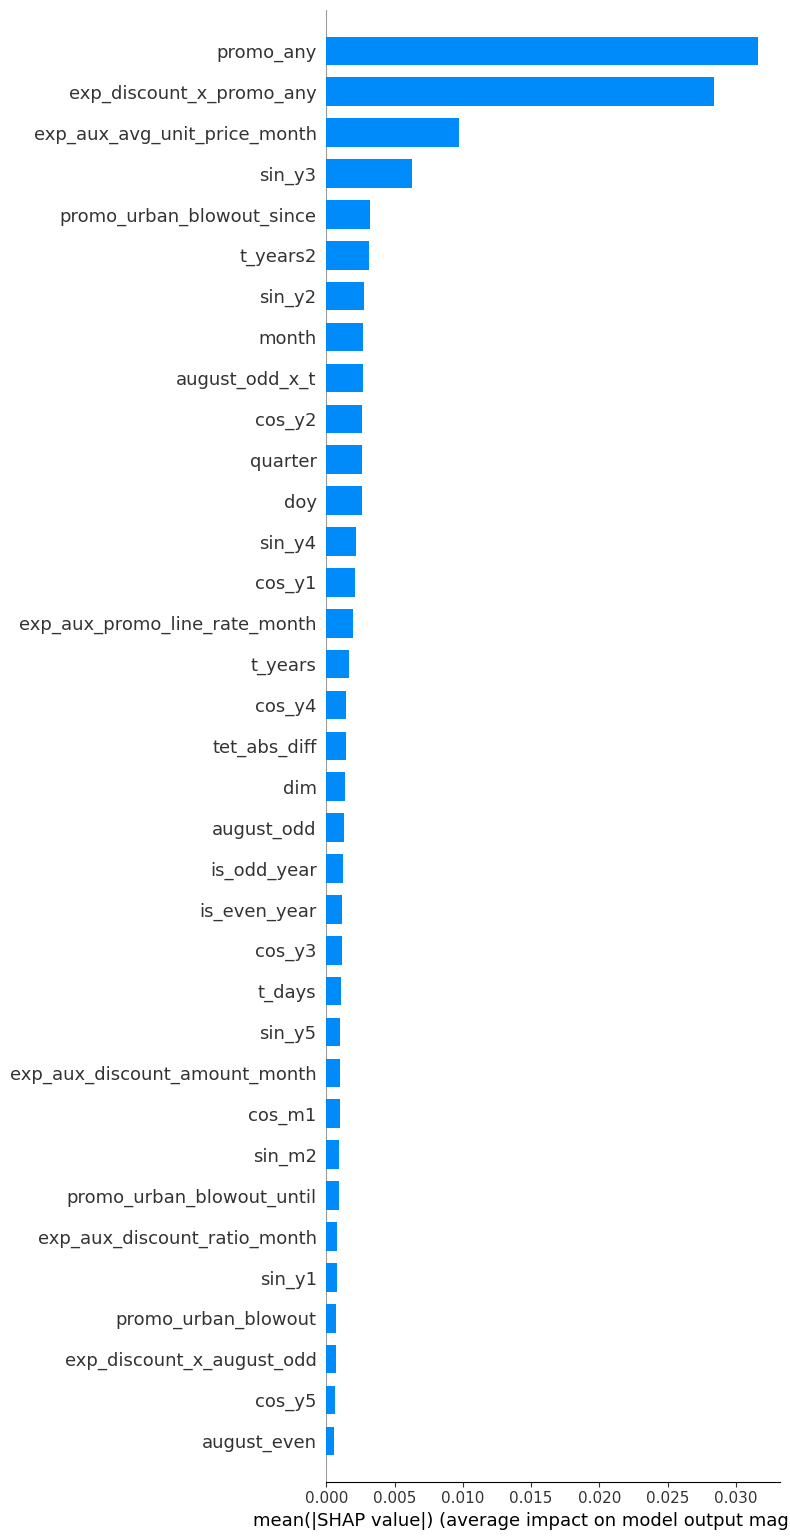


GROUP IMPORTANCE:


,group,n_features,group_shap_sum,top_features
0,discount_promo,35,0.074143,"[promo_any, exp_discount_x_promo_any, promo_ur..."
1,trend_regime,48,0.064349,"[exp_discount_x_promo_any, exp_aux_avg_unit_pr..."
2,calendar_seasonality,37,0.047862,"[exp_aux_avg_unit_price_month, sin_y3, promo_u..."
3,inventory,2,0.000875,"[inv_sellthrough_x_august, inv_sellthrough_x_p..."
4,margin_cost,1,0.000783,[exp_aux_discount_ratio_month]
5,category_streetwear_outdoor,0,0.000000,[]
6,traffic,0,0.000000,[]


In [15]:
# =========================================================
# SHAP FEATURE IMPORTANCE
# Compatible with current K-Fold pipeline:
#   rev_lgb_f, rev_cat_f, margin_lgb_f, margin_cat_f
#   X_rev_tr, X_margin_tr
#   cols_rev, cols_margin
# =========================================================

!pip -q install shap

import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# Convert to DataFrame
# =========================================================

X_rev_shap = pd.DataFrame(X_rev_tr, columns=cols_rev)
X_margin_shap = pd.DataFrame(X_margin_tr, columns=cols_margin)

N_SAMPLE = min(2000, len(X_rev_shap))

X_rev_sample = X_rev_shap.sample(N_SAMPLE, random_state=42)
X_margin_sample = X_margin_shap.sample(N_SAMPLE, random_state=42)

# =========================================================
# Pick models from last K-fold
# =========================================================

models_to_check = {
    "Revenue_LGB_last_fold": (rev_lgb_f, X_rev_sample),
    "Revenue_CAT_last_fold": (rev_cat_f, X_rev_sample),
    "Margin_LGB_last_fold": (margin_lgb_f, X_margin_sample),
    "Margin_CAT_last_fold": (margin_cat_f, X_margin_sample),
}

# =========================================================
# SHAP helper
# =========================================================

def run_shap(model, X_sample, title, max_display=35):
    print("\n" + "=" * 90)
    print(title)
    print("=" * 90)

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_sample)

    if isinstance(shap_values, list):
        shap_values = shap_values[0]

    if len(shap_values.shape) == 3:
        shap_values = shap_values[:, :, 0]

    imp = pd.DataFrame({
        "feature": X_sample.columns,
        "mean_abs_shap": np.abs(shap_values).mean(axis=0)
    }).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

    display(imp.head(max_display))

    shap.summary_plot(
        shap_values,
        X_sample,
        max_display=max_display,
        show=True
    )

    shap.summary_plot(
        shap_values,
        X_sample,
        plot_type="bar",
        max_display=max_display,
        show=True
    )

    # =====================================================
    # Feature group diagnostic
    # =====================================================

    group_keywords = {
        "category_streetwear_outdoor": [
            "streetwear", "outdoor", "cat_month"
        ],
        "calendar_seasonality": [
            "month", "quarter", "dow", "week", "sin", "cos"
        ],
        "trend_regime": [
            "t_", "trend", "post", "regime", "year"
        ],
        "traffic": [
            "web", "session", "traffic", "visitor", "page"
        ],
        "discount_promo": [
            "discount", "promo"
        ],
        "inventory": [
            "inv_", "stock", "supply", "sell_through"
        ],
        "margin_cost": [
            "margin", "ratio", "cogs", "cost"
        ],
    }

    rows = []

    for group, keys in group_keywords.items():
        feats = [
            f for f in imp["feature"]
            if any(k.lower() in f.lower() for k in keys)
        ]

        score = imp.loc[
            imp["feature"].isin(feats),
            "mean_abs_shap"
        ].sum()

        rows.append({
            "group": group,
            "n_features": len(feats),
            "group_shap_sum": score,
            "top_features": feats[:8]
        })

    group_df = (
        pd.DataFrame(rows)
        .sort_values("group_shap_sum", ascending=False)
        .reset_index(drop=True)
    )

    print("\nGROUP IMPORTANCE:")
    display(group_df)


    return imp, group_df


# =========================================================
# Run SHAP
# =========================================================

shap_results = {}

for name, (model, X_sample) in models_to_check.items():
    imp, group_imp = run_shap(
        model=model,
        X_sample=X_sample,
        title=name,
        max_display=35
    )

    shap_results[name] = {
        "importance": imp,
        "group_importance": group_imp
    }
